# Cosmology with GWs/FRBs Associations MCMC version

In [2]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

### MCMCM packages
path='../FRB_cosmo/interpolation/095_C0mean.npz' # './interpolation/StandardD_C0mean.npz' 

import mcmc_support_GW_FRB_DM_diff
mcmc_support_GW_FRB_DM_diff.DATA_PATH = path
mcmc_support_GW_FRB_DM_diff.reload_with_path(path)
from mcmc_support_GW_FRB_DM_diff import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


-------------------------------------------------------------

# Table of Contents <a name="toc"></a>

1. [Basic definitions](#Definitions)
2. [Checking with Wei et al.](#Reproduction_Results_Wei_et_al)
3. [Cosmo inference without redshift - precise distance info](#Precise_distance_info)
4. [Cosmo inference without redshift - uncertain distance info](#Uncertain_distance_info)
5. [Finding the missing baryons with Macquart et al.](#Macquart_paper)

----------------------------------------------

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, we have $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

-----------------------------------------

## 1. $D_L$ & $DM_{diff}$ constraints <a name="D_L DM_diff"></a>

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. ${\rm DM}^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

Return to TOC [here](#toc).

In [3]:
interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')

LVK_linear = interpolations['LVK_interpolation']
CE_linear = interpolations['CE_interpolation']

In [4]:
# Find use quadratic function may get negative error in some large redshift

def func_lin(x, a0, a1):
    return a0+a1*x


def GW_error_LVK(z, H0, Om, w=-1, order=1):
    if (order==1):
        sigma_ratio = func_lin(z, *LVK_linear)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif (order==2):
        a0=17.015
        a1=131.750
        a2=-174.911
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')
    
def GW_error_CE(z, H0, Om, w=-1, order=1):
    if (order==1):
        sigma_ratio = func_lin(z, *CE_linear)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif (order==2):
        a0=7.649
        a1=18.581
        a2=-4.559
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')

## Generate events

**For FRB DM, try to use Macquart pdf**

$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$

$$ <DM_{diff}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

$ p_{diff}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{diff}^2}\right) $

$ \sigma_{diff} $ dominated by physical variance in $DM_{diff}$

$\Delta=DM_{diff}/<DM_{diff}>$

$ \sigma_{diff}(\sigma_{\Delta}(S,z)) $

Which 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$ in Macquart paper.

### Load interpolation

In [5]:
""" S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
DM_MWHALO=30
HOF=2.813

load_arrays=np.load('../FRB_cosmo/interpolation/095_C0mean.npz')
# load_arrays=np.load('./interpolation/StandardD_C0mean.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
    fill_value='extrapolate'
    )    
    
## Interpolation of C0 terms (see Macquart+ paper)
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    fill_value='extrapolate'
    )

## Interpolation of normalisation factor (so that pdf is normalised to 1)
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    fill_value='extrapolate'
) """

" S=0.133\nEXP_MU=182.937\nSIGMA_HOST=0.605\nDM_MWHALO=30\nHOF=2.813\n\nload_arrays=np.load('../FRB_cosmo/interpolation/095_C0mean.npz')\n# load_arrays=np.load('./interpolation/StandardD_C0mean.npz')\nSigmas=load_arrays['a']\nErrors=load_arrays['d']\nC0s=load_arrays['c']\nAs=load_arrays['b']\n\nsigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n    )    \n    \n## Interpolation of C0 terms (see Macquart+ paper)\nC0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n    )\n\n## Interpolation of normalisation factor (so that pdf is normalised to 1)\nA_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n) "

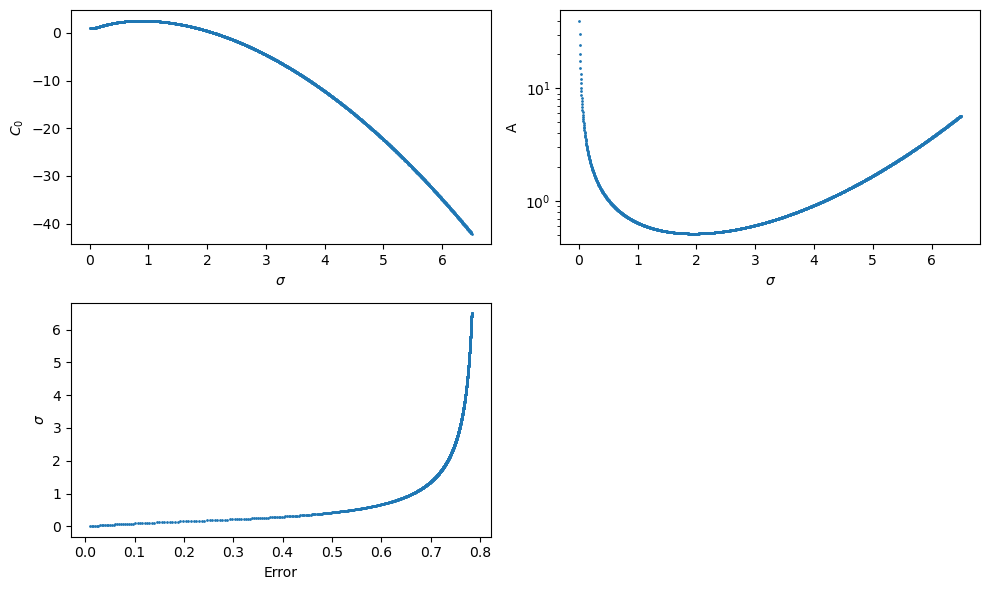

In [6]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.scatter(Sigmas, C0s,  s=1)
ax1.set_ylabel(r'$C_0$')
ax1.set_xlabel(r'$\sigma$')

ax2.scatter(Sigmas, As,  s=1)
ax2.set_ylabel('A')
ax2.set_xlabel(r'$\sigma$')
ax2.set_yscale('log')

ax3.scatter(Errors, Sigmas,s=1)
ax3.set_ylabel(r'$\sigma$')
ax3.set_xlabel(r'Error')

plt.tight_layout()
plt.show()

### Cosmological constraints

Generate events from $p_\Delta(\Delta)$. Note that $p_{DM_{diff}}(DM_{diff})d DM_{diff}=p_\Delta(\Delta) d\Delta$, so we have $p_{DM_{diff}}(DM_{diff})=p_\Delta(\Delta) /<DM>$

Now take into account that distances & $DM_{diff}$. To calculate the cosmological parameters, we'll follow a Bayesian approach:

$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \pi(\mathbf{H_0}) \cdot P(d_L^{\rm obs}, {\rm DM}^{\rm obs}|\mathbf{H_0}) = \\
\pi(\mathbf{H_0}) \int dz \ P\left(d_L^{\rm obs}|d_L(z,\mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) \cdot \pi(z)
$$
where with $\mathbf{H_0}$ we denote the _vector_ of cosmological parameters ($H_0, \Omega_m, w$) and $\pi(z)$ is the prior on the redshift distribution of sources and $\pi(\mathbf{H_0})$ the priors on the cosmological parameters. 

For the ${\rm DM}$ part, we can introduce the contributions of different sources as systematic errors and marginalise over them. In reality, we can estimate ${\rm DM}_{\rm diff}$ as:

$$
{\rm DM}_{\rm diff} = {\rm DM}_{\rm obs} - {\rm DM}_{\rm MW} - {\rm DM}_{\rm host}/(1+z), 
$$

where ${\rm DM}_{\rm MW} = {\rm DM}_{\rm MW, halo} + {\rm DM}_{\rm MW, ISM}$. So we can write $P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right)$ as:

$$
P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) = \int d{\rm DM}^{\rm MW} d{\rm DM}^{\rm HG} \pi({\rm DM}^{\rm MW}) \pi({\rm DM}^{\rm HG}) P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}), {\rm DM}^{\rm MW}, {\rm DM}^{\rm HG} \right).
$$

We infer:

- $H_0$ with $\Omega_m, w$ fixed to their fiducial values
- $H_0, \Omega_m$ with $w$ fixed to its fiducial value
- $H_0, \Omega_m, w$

#### Simplified version: **$p(z)\sim 1$**

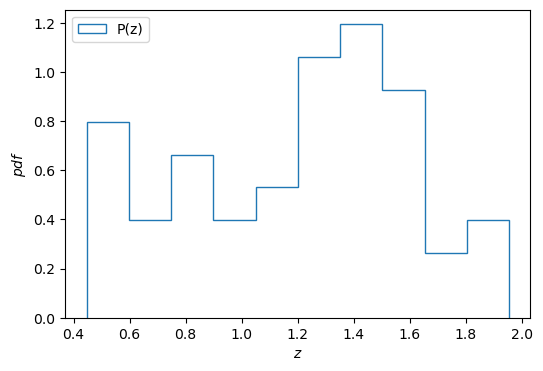

In [7]:
""" ## Random choice of redshift
z_range = np.linspace(0.25, 2, 500)
z_centre = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=20, method='rates') """

fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(z_centre, density=True, histtype='step', label='P(z)')
# ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

In [8]:
print(f"z={z_centre}")

z=[0.60420842 0.79709419 0.91282565 0.56913828 1.31963928 1.4248497
 1.85621242 0.51653307 0.46392786 0.74448898 0.55160321 0.9759519
 1.01803607 1.48096192 0.81112224 1.24599198 1.17234469 0.8496994
 1.34068136 1.1758517  1.58266533 0.65330661 0.44639279 1.59318637
 1.28456914 1.41082164 1.13376754 1.95440882 1.4739479  1.46342685
 1.76152305 1.29158317 1.23196393 1.40380762 0.84268537 1.16533066
 0.54809619 1.68787575 1.53356713 1.39328657 1.49849699 0.88827655
 1.83517034 1.54759519 1.50901804 1.51252505 1.2249499  1.24599198
 1.61072144 1.37925852]


In [9]:
""" dL_centre = luminosity_distance(z_centre)
DM_centre = dispersion_measure(z_centre, H0=HUBBLE, Om=OMEGA_MATTER) """

print(f"dL={dL_centre} Mpc, DM={DM_centre} pc/cm^3")

dL=[ 3669.03897731  5143.16477401  6075.1731485   3413.18910169
  9570.01624467 10518.83326735 14555.88228404  3037.27571418
  2671.36428472  4730.66265761  3286.81352215  6596.56558557
  6948.87214304 11031.19824481  5254.38661557  8915.70465684
  8270.15516713  5562.79324579  9758.49086295  8300.68787629
 11970.29199306  4033.88672756  2551.73336781 12068.17313636
  9257.38388303 10391.41220095  7935.7163818  15502.98568963
 10966.92214555 10870.63015283 13651.68280462  9319.75895435
  8792.04892258 10327.80438599  5506.44627715  8209.15368322
  3261.6652555  12954.96963367 11515.30649279 10232.52221597
 11192.17080579  5874.80877874 14354.15784789 11644.99736723
 11288.94609259 11321.23620805  8730.34149855  8915.70465684
 12231.6037623  10105.72334323] Mpc, DM=[ 543.80835581  724.48831718  832.25517976  510.94663362 1202.72223276
 1295.88502981 1665.27764906  461.72726706  412.65333203  675.29107858
  494.52813344  890.67949643  929.46212125 1345.08583193  737.58870742
 1136.816607

In [10]:
## Choice of observed luminosity distance

# Use this for fixed error/redshift
# sigma_dL = 0.1*dL_centre

# Use this for redshift dependent errors
sigma_dL = GW_error_CE(z_centre, H0=HUBBLE, Om=OMEGA_MATTER)


dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

DM_obs_centre=np.zeros_like(z_centre)
s_DM_obs = np.zeros_like(z_centre)

for idx, z_val in enumerate(z_centre):
    DM_obs_centre[idx], s_DM_obs[idx] = DM_diff_sampling(z=z_val, 
                                                       S=S, HOF=HOF,
                                                       sigma_error_inter=sigma_error_inter,
                                                       C0_sigma_inter=C0_sigma_inter,
                                                       A_sigma_inter=A_sigma_inter,
                                                       H0=HUBBLE, f_diff=0.84, f_diff_alpha=0,
                                                       Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                                                       mode=None #'standard'
                                                       )

# print(f"dL_obs={dL_obs_centre} Mpc, DM_obs={DM_obs_centre} pc/cm^3")

/tmp/ipykernel_1806/2461506488.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  DM_obs_centre[idx], s_DM_obs[idx] = DM_diff_sampling(z=z_val,


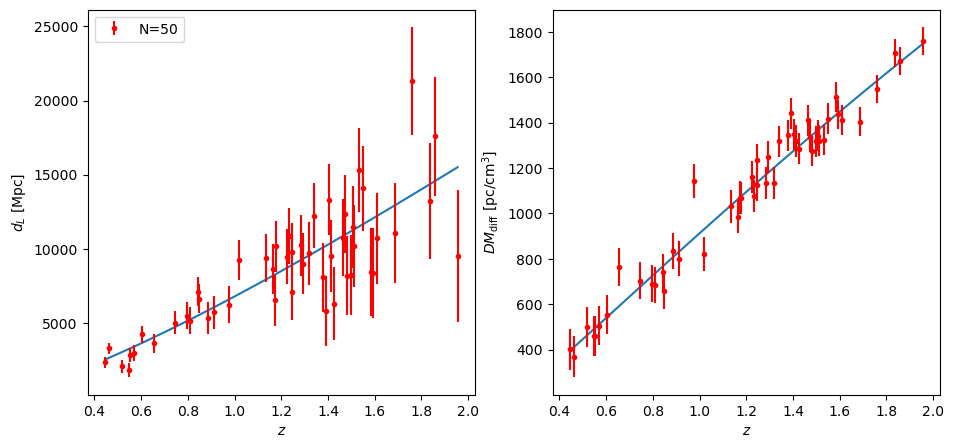

In [ ]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(z_centre), np.sort(dL_centre))
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(z_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_centre), np.sort(DM_centre))
ax2.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'$DM_{\rm diff}$ [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.savefig('./plot/dL_DM_diff.pdf')
# plt.tight_layout()
plt.show()

In [12]:
events=pd.DataFrame({
    'z': z_centre,
    'dL': dL_centre,
    'dL_obs': dL_obs_centre,
    's_dL': sigma_dL,
    'DM': DM_centre,
    'DM_obs': DM_obs_centre,
    's_DM': s_DM_obs
})
events.head()

,z,dL,dL_obs,s_dL,DM,DM_obs,s_DM
0,0.604208,3669.038977,4255.014908,568.955148,543.808356,554.247479,85.769061
1,0.797094,5143.164774,5497.676414,893.035424,724.488317,691.026617,80.558841
2,0.912826,6075.173148,5738.683011,1122.540547,832.255180,800.231289,77.823680
3,0.569138,3413.189102,2998.497473,517.758930,510.946634,506.197110,86.817762
4,1.319639,9570.016245,9693.451229,2143.039899,1202.722233,1134.548858,69.953891


In [16]:
# initial parameters
Hubble0 = 70
Omega0 = 0.3
w0 = -1.0

# MCMC parameters
N_WALKERS = 32
HEATING = 500
N_STEPS = 1000

In [17]:
# Main execution
if __name__ == "__main__":

    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([Hubble0, Omega0, w0])

    # Run MCMC
    sampler = run_mcmc(events, initial_params, nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS)

Running MCMC...
heating...


  0%|          | 0/500 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Analyze results
samples, params_median, params_errors = mcmc_analyze_results(sampler, burn_in=HEATING)

# Print results
param_names = [r'$ H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']
print("MCMC Results:")
for i, name in enumerate(param_names):
    print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")

# Save samples to file for later analysis if needed
np.save('./posterior/GW_FRB_MCMC.npy', samples)

MCMC Results:
$ H_0$  = 62.341 ± 1.208
$ \Omega_m$  = 0.003 ± 0.004
$ w$  = -2.540 ± 0.409


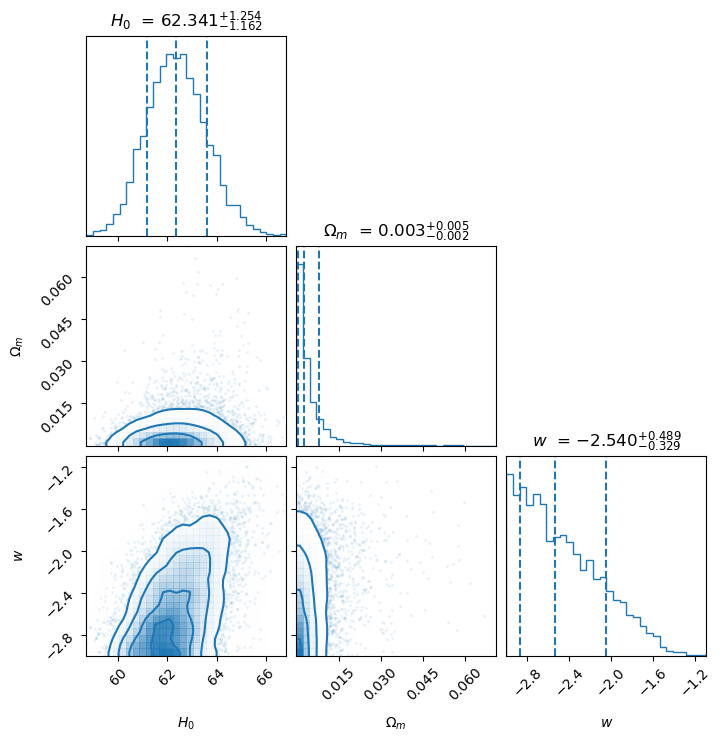

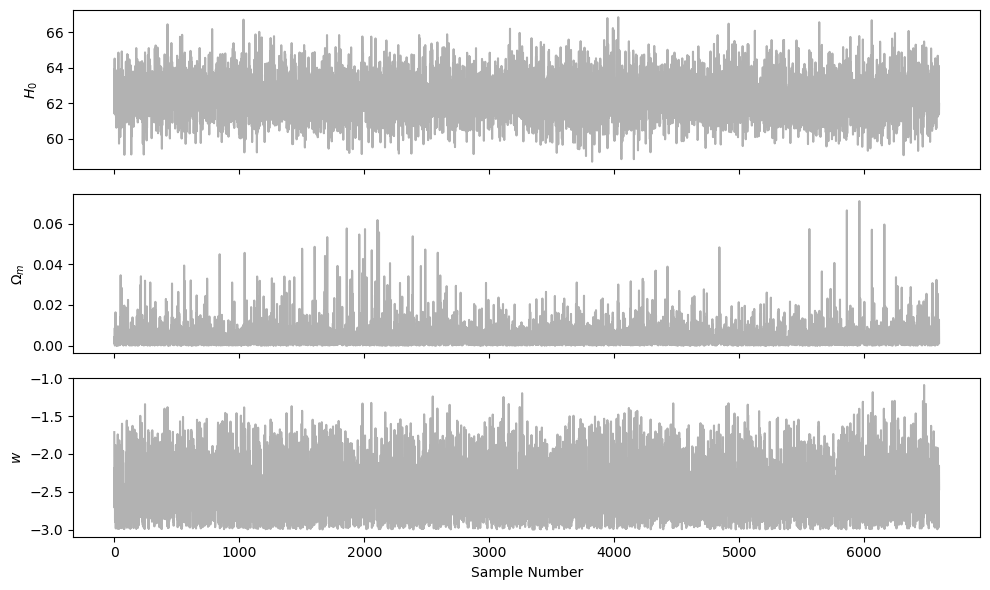

In [ ]:
param_names = [r'$ H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']

mcmc_plot_results(samples, param_names, savetitle='./plot/MCMC_DM_diff')